In [3]:
import vectorbt as vbt
import pandas as pd
from datetime import datetime

# 1. Definir el universo de activos de alta liquidez y el rango de 5 años
assets = ['BTC-USD', 'ETH-USD', 'SOL-USD']
start_date = '2021-05-31'  # 5 años atrás desde el presente en 2026
end_date = '2026-05-31'

print("Descargando datos históricos desde Yahoo Finance a través de VectorBT...")

# 2. Descarga masiva de precios de cierre ajustados
data = vbt.YFData.download(assets, start=start_date, end=end_date)
close_prices = data.get('Close')

# 3. Mostrar las primeras líneas y verificar que no existan datos nulos
print("\n¡Datos descargados con éxito!")
print(f"Total de registros: {len(close_prices)} días de mercado continuo.")
print(close_prices.head())

Descargando datos históricos desde Yahoo Finance a través de VectorBT...

¡Datos descargados con éxito!
Total de registros: 1827 días de mercado continuo.
symbol                          BTC-USD      ETH-USD    SOL-USD
Date                                                           
2021-05-31 00:00:00+00:00  37332.855469  2714.945312  32.816246
2021-06-01 00:00:00+00:00  36684.925781  2633.518311  30.985260
2021-06-02 00:00:00+00:00  37575.179688  2706.125000  33.956318
2021-06-03 00:00:00+00:00  39208.765625  2855.126465  39.470905
2021-06-04 00:00:00+00:00  36894.406250  2688.195068  37.415070


In [15]:
import numpy as np
import pandas as pd
from arch import arch_model

# 1. Calcular rendimientos logarítmicos diarios
returns = np.log(close_prices / close_prices.shift(1)).dropna()

print("Calibrando modelos GJR-GARCH(1,1,1) con Distribución Skew-t...")

# 2. Matriz para almacenar la volatilidad condicional
garch_vol = pd.DataFrame(index=returns.index, columns=returns.columns)

for asset in assets:
    model = arch_model(
        returns[asset] * 100, 
        vol='Garch', 
        p=1, 
        o=1, 
        q=1, 
        dist='skewt'
    )
    res = model.fit(disp='off')
    garch_vol[asset] = res.conditional_volatility / 100

# 3. Construir Canales de Donchian (20 días)
window = 20
upper_band = close_prices.rolling(window=window).max()
lower_band = close_prices.rolling(window=window).min()

# Generar señales puras de Momentum
momentum_signal = pd.DataFrame(0, index=close_prices.index, columns=close_prices.columns)
momentum_signal[close_prices >= upper_band.shift(1)] = 1
momentum_signal[close_prices <= lower_band.shift(1)] = -1

# 4. NUEVO AJUSTE: Filtro de Volatilidad con Percentil Rodante de 90 días
# El umbral ya no es un número fijo; evoluciona dinámicamente día con día
rolling_window = 90
vol_threshold = garch_vol.rolling(window=rolling_window, min_periods=20).quantile(0.75)

# Si la volatilidad actual es menor que el umbral de los últimos 90 días, damos luz verde
garch_filter = garch_vol < vol_threshold

final_signals = momentum_signal.copy()
# Bloquear compras solo si la volatilidad rompe el régimen local de pánico
final_signals[(momentum_signal == 1) & (~garch_filter)] = 0

print("\n¡Modelo híbrido avanzado (Asimétrico + Umbral Dinámico) finalizado!")
print("Señales actualizadas en la memoria del Kernel.")

Calibrando modelos GJR-GARCH(1,1,1) con Distribución Skew-t...

¡Modelo híbrido avanzado (Asimétrico + Umbral Dinámico) finalizado!
Señales actualizadas en la memoria del Kernel.


In [16]:
import vectorbt as vbt

# 1. Aislar las condiciones de entrada y salida para el motor de ejecución
# Entries: Señales de compra que pasaron el filtro dinámico GARCH
entries = (final_signals == 1)
# Exits: Ruptura del canal inferior de Donchian (cambio de tendencia estructural)
exits = (momentum_signal == -1)

print("Ejecutando simulación histórica en el motor de VectorBT...")

# 2. Inicializar el portafolio aplicando $1,000 de capital inicial por activo
# Agregamos un 0.1% (0.001) de comisión por operación para simular la fricción real de un Exchange
portfolio = vbt.Portfolio.from_signals(
    close=close_prices,
    entries=entries,
    exits=exits,
    init_cash=1000,
    fees=0.001,
    freq='D'
)

# 3. Desplegar la sábana de métricas de rendimiento (Sharpe, Max Drawdown, Retorno Total)
print("\n=== REPORTE CUANTITATIVO (GJR-GARCH + SKEW-T + ROLLING QUANTILE) ===")
print(portfolio.stats())

# 4. Renderizar el gráfico interactivo de retornos acumulados vs Buy & Hold pasivo
print("\nGenerando gráfico de rendimiento...")
portfolio.plot_cumulative_returns().show()

Ejecutando simulación histórica en el motor de VectorBT...

=== REPORTE CUANTITATIVO (GJR-GARCH + SKEW-T + ROLLING QUANTILE) ===
Start                          2021-05-31 00:00:00+00:00
End                            2026-05-31 00:00:00+00:00
Period                                1827 days 00:00:00
Start Value                                       1000.0
End Value                                    6972.296019
Total Return [%]                              597.229602
Benchmark Return [%]                           72.866048
Max Gross Exposure [%]                             100.0
Total Fees Paid                               235.981822
Max Drawdown [%]                               62.590829
Max Drawdown Duration                  976 days 00:00:00
Total Trades                                   26.666667
Total Closed Trades                            26.666667
Total Open Trades                                    0.0
Open Trade PnL                                       0.0
Win Rate [%]    

C:\Users\jesus\AppData\Local\Temp\ipykernel_24608\3228129066.py:24: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x000001A943A44180>. Pass column to select a single column/group.



AttributeError: 'Portfolio' object has no attribute 'plot_cumulative_returns'

<Axes: title={'center': 'Curva de Rendimiento Acumulado - Portafolio Cripto'}, xlabel='Date'>

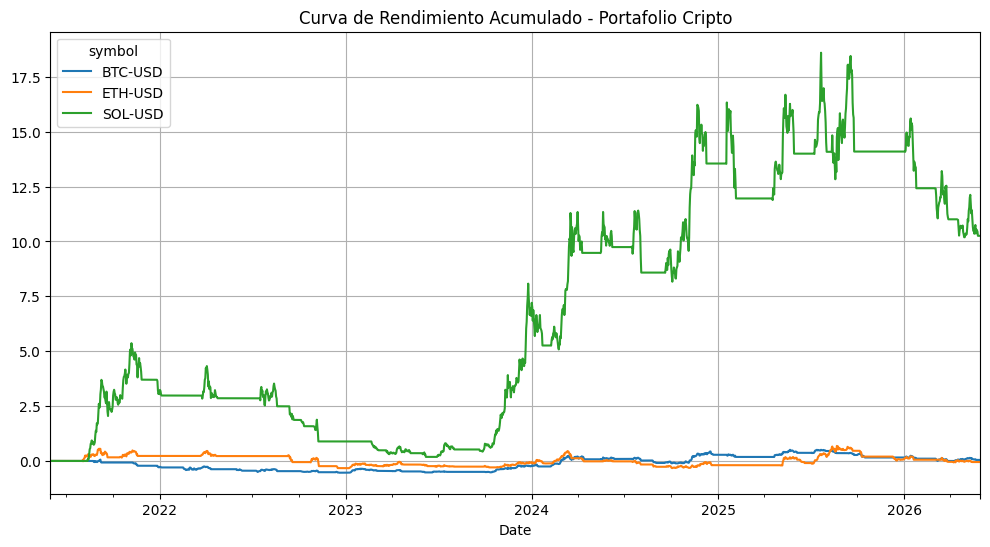

In [10]:
# Extraer la matriz de retornos acumulados calculada por el motor
retornos_acumulados = portfolio.cumulative_returns()

# Graficar usando el motor clásico y liviano de Matplotlib
retornos_acumulados.plot(
    figsize=(12, 6), 
    grid=True, 
    title="Curva de Rendimiento Acumulado - Portafolio Cripto"
)

In [11]:
import plotly.io as pio

# Forzar a Plotly a usar el visor interno directo de VS Code
pio.renderers.default = "vscode"

# Volver a lanzar el gráfico de VectorBT
portfolio.cumulative_returns().vbt.plot()

FigureWidget({
    'data': [{'name': 'BTC-USD',
              'showlegend': True,
              'type': 'scatter',
              'uid': '85c11739-5b3e-4231-9de6-75bb276fbadf',
              'x': array([datetime.datetime(2021, 5, 31, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2021, 6, 1, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2021, 6, 2, 0, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2026, 5, 29, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2026, 5, 30, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2026, 5, 31, 0, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([0.        , 0.        , 0.        , ..., 0.04647833, 0.04647833,
                          0.04647833])},
             {'name': 'ETH-USD',
              'showlegend': True,
              'ty

In [12]:
import numpy as np
import pandas as pd
from arch import arch_model

# 1. Calcular rendimientos logarítmicos diarios
returns = np.log(close_prices / close_prices.shift(1)).dropna()

print("Calibrando modelos GJR-GARCH(1,1,1) con Distribución Skew-t...")

# 2. Matriz para almacenar la nueva volatilidad condicional
garch_vol = pd.DataFrame(index=returns.index, columns=returns.columns)

for asset in assets:
    # Parámetros Institucionales:
    # p=1 (Choque de volatilidad de ayer)
    # o=1 (Componente de Asimetría / Efecto Apalancamiento ante caídas)
    # q=1 (Persistencia de la volatilidad a largo plazo)
    # dist='skewt' (Captura colas pesadas y sesgo direccional de retornos)
    model = arch_model(
        returns[asset] * 100, 
        vol='Garch', 
        p=1, 
        o=1, 
        q=1, 
        dist='skewt'
    )
    
    # Correr el optimizador numérico en modo silencioso
    res = model.fit(disp='off')
    
    # Guardar la volatilidad condicional diaria corregida (reescalada a base 1)
    garch_vol[asset] = res.conditional_volatility / 100

# 3. Construir Canales de Donchian (20 días)
window = 20
upper_band = close_prices.rolling(window=window).max()
lower_band = close_prices.rolling(window=window).min()

# Generar señales puras de Momentum
momentum_signal = pd.DataFrame(0, index=close_prices.index, columns=close_prices.columns)
momentum_signal[close_prices >= upper_band.shift(1)] = 1
momentum_signal[close_prices <= lower_band.shift(1)] = -1

# 4. Aplicar el Filtro Dinámico Asimétrico
# Usamos el percentil 75 histórico como límite de riesgo máximo admisible
vol_threshold = garch_vol.quantile(0.75)
garch_filter = garch_vol < vol_threshold

final_signals = momentum_signal.copy()
# Bloquear compras si la volatilidad asimétrica se dispara a zona de pánico
final_signals[(momentum_signal == 1) & (~garch_filter)] = 0

print("\n¡Modelado asimétrico avanzado finalizado con éxito!")
print("Nueva volatilidad promedio anualizada (GJR-GARCH + Skew-t):")
print((garch_vol.mean() * np.sqrt(252) * 100).round(2).astype(str) + '%')

Calibrando modelos GJR-GARCH(1,1,1) con Distribución Skew-t...

¡Modelado asimétrico avanzado finalizado con éxito!
Nueva volatilidad promedio anualizada (GJR-GARCH + Skew-t):
symbol
BTC-USD    47.66%
ETH-USD    61.69%
SOL-USD     80.2%
dtype: object


Entrenando el cerebro de Machine Learning (HMM) para regímenes estructurales...
Calibrando volatilidad asimétrica con modelos GJR-GARCH + Skew-t...
Simulando ejecución en paralelo con VectorBT aplicando comisiones de mercado...

=== REPORTE CUANTITATIVO DEL MODELO SISTÉMICO DE TRADING (HMM + GARCH) ===
Start                          2021-05-31 00:00:00+00:00
End                            2026-05-31 00:00:00+00:00
Period                                1827 days 00:00:00
Start Value                                       1000.0
End Value                                    8259.286536
Total Return [%]                              725.928654
Benchmark Return [%]                           72.866048
Max Gross Exposure [%]                             100.0
Total Fees Paid                               233.375011
Max Drawdown [%]                               59.344855
Max Drawdown Duration                  974 days 16:00:00
Total Trades                                   23.666667
Total Closed

C:\Users\jesus\AppData\Local\Temp\ipykernel_24608\1958374113.py:97: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x000001A943A44180>. Pass column to select a single column/group.



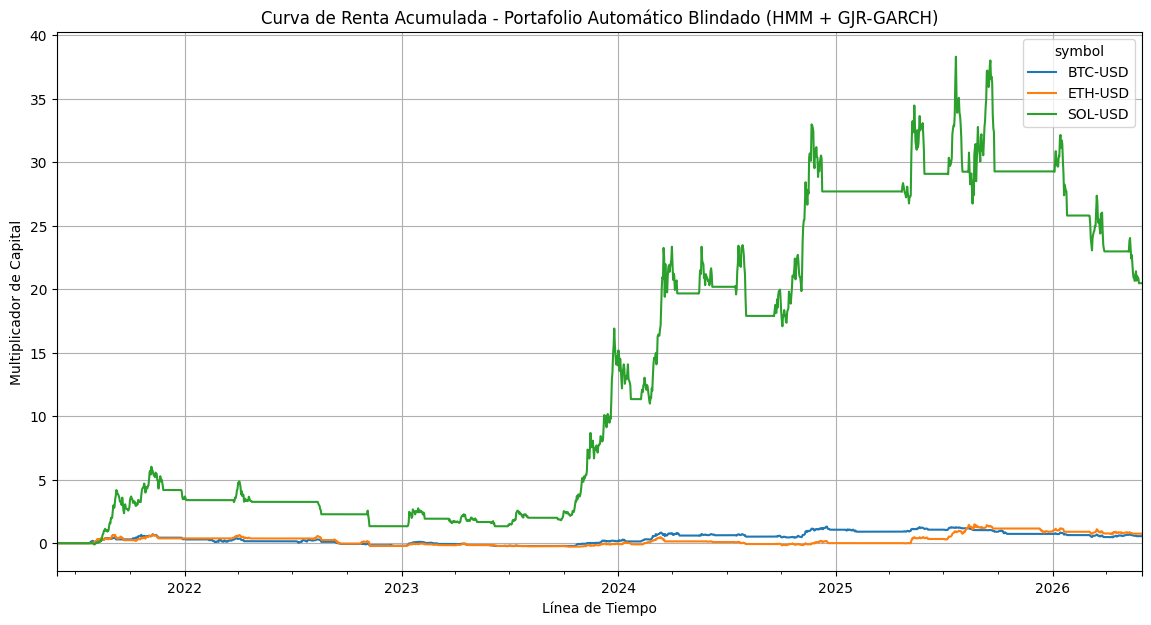

In [17]:
import numpy as np
import pandas as pd
import vectorbt as vbt
from arch import arch_model
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# 1. Calcular rendimientos logarítmicos del universo de activos
returns = np.log(close_prices / close_prices.shift(1)).dropna()

# =========================================================================
# CAPA 1: MACHINE LEARNING - DETECCIÓN DE RÉGIMEN CON HIDDEN MARKOV MODEL
# =========================================================================
print("Entrenando el cerebro de Machine Learning (HMM) para regímenes estructurales...")

# Creamos un índice macro promediando los retornos diarios del mercado cripto
macro_index = returns.mean(axis=1).to_frame('macro_returns')

# Inicializar un modelo de Markov de 3 estados ocultos (Alcista, Bajista, Lateral)
# Fijamos el random_state para garantizar que el backtest sea reproducible
hmm = GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
hmm.fit(macro_index)
regimes = hmm.predict(macro_index)

# Ordenamos los estados basados en su media matemática para estandarizar las etiquetas:
# Estado 0 = Tendencia Bajista (Pánico), Estado 1 = Lateral (Chop/Ruido), Estado 2 = Tendencia Alcista
state_means = [hmm.means_[i][0] for i in range(3)]
ordered_states = np.argsort(state_means)

hmm_regimes_df = pd.DataFrame(regimes, index=macro_index.index, columns=['state'])

# Clasificar los estados que representan peligro estructural o ruido sin tendencia
market_is_bad_or_choppy = hmm_regimes_df['state'].isin([ordered_states[0], ordered_states[1]])
market_is_bad_or_choppy = market_is_bad_or_choppy.reindex(close_prices.index, method='ffill').fillna(True)

# Expandir la máscara de ML a una matriz con las dimensiones exactas de nuestro portafolio
hmm_block_mask = pd.DataFrame(
    np.repeat(market_is_bad_or_choppy.values.reshape(-1, 1), len(assets), axis=1),
    index=close_prices.index,
    columns=close_prices.columns
)

# =========================================================================
# CAPA 2: SOFISTICACIÓN MATEMÁTICA - FILTRO DE RIESGO ASIMÉTRICO GJR-GARCH
# =========================================================================
print("Calibrando volatilidad asimétrica con modelos GJR-GARCH + Skew-t...")
garch_vol = pd.DataFrame(index=returns.index, columns=returns.columns)

for asset in assets:
    # Captura pánico (o=1), persistencia (p=1, q=1) y colas pesadas (dist='skewt')
    model = arch_model(returns[asset] * 100, vol='Garch', p=1, o=1, q=1, dist='skewt')
    res = model.fit(disp='off')
    garch_vol[asset] = res.conditional_volatility / 100

# Dinamizar el límite con un Percentil Rodante de 90 días
vol_threshold = garch_vol.rolling(window=90, min_periods=20).quantile(0.75)
garch_filter = garch_vol < vol_threshold
garch_filter = garch_filter.reindex(close_prices.index, method='ffill').fillna(False)

# =========================================================================
# CAPA 3: GATILLO DE EJECUCIÓN (DONCHIAN 20D) Y FILTRADO MULTICAPA
# =========================================================================
window = 20
upper_band = close_prices.rolling(window=window).max()
lower_band = close_prices.rolling(window=window).min()

# Señales de momentum puro
momentum_signal = pd.DataFrame(0, index=close_prices.index, columns=close_prices.columns)
momentum_signal[close_prices >= upper_band.shift(1)] = 1
momentum_signal[close_prices <= lower_band.shift(1)] = -1

# FILTRADO CRÍTICO: Modificar las señales originales aplicando el Pipeline combinando ML y Matemáticas
final_signals = momentum_signal.copy()

# Bloqueamos quirúrgicamente la entrada en largo si:
# 1. El GARCH dice que el riesgo local excedió el percentil 75 (~garch_filter) OR
# 2. El Machine Learning detecta que el mercado macro está en rango ruidoso o caída (hmm_block_mask)
final_signals[(momentum_signal == 1) & ((~garch_filter) | hmm_block_mask)] = 0

# =========================================================================
# 4. MOTOR DE EJECUCIÓN SENSÍBLE A COMISIONES (VECTORBT)
# =========================================================================
print("Simulando ejecución en paralelo con VectorBT aplicando comisiones de mercado...")
entries = (final_signals == 1)
exits = (momentum_signal == -1)

portfolio_fund = vbt.Portfolio.from_signals(
    close=close_prices,
    entries=entries,
    exits=exits,
    init_cash=1000,
    fees=0.001,
    freq='D'
)

print("\n=== REPORTE CUANTITATIVO DEL MODELO SISTÉMICO DE TRADING (HMM + GARCH) ===")
print(portfolio_fund.stats())

# Generar el gráfico de renta acumulada estático para auditar la evolución de los $1,000
portfolio_fund.cumulative_returns().plot(
    figsize=(14, 7), 
    grid=True, 
    title="Curva de Renta Acumulada - Portafolio Automático Blindado (HMM + GJR-GARCH)"
)
plt.ylabel("Multiplicador de Capital")
plt.xlabel("Línea de Tiempo")
plt.show()

In [2]:
!pip install yfinance

   ---------------------------------------- 0.0/137.8 kB ? eta -:--:--
   ----------------- ---------------------- 61.4/137.8 kB 1.1 MB/s eta 0:00:01
   ----------------------------------- ---- 122.9/137.8 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 137.8/137.8 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/107.7 kB ? eta -:--:--
   ---------------------------------------- 107.7/107.7 kB 3.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---- ----------------------------------- 0.2/1.7 MB 12.2 MB/s eta 0:00:01
   ---------------- ----------------------- 0.7/1.7 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------  1.6/1.7 MB 13.1 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 11.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/146.2 kB ? eta -:--:--
   ---------------------------------------- 146.2/146.2 kB 9.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.covariance import ledoit_wolf
import scipy.optimize as sco

# =========================================================================
# 1. CONFIGURACIÓN DEL PORTAFOLIO: AQUÍ ESTÁN TUS ACCIONES
# =========================================================================
# Definimos los pilares del S&P 500 que vamos a optimizar
assets = ['MSFT', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG']
benchmark = ['SPY']

initial_capital = 1000
rf_rate = 0.04  # Tasa libre de riesgo (4%)

print("1. Descargando datos históricos de las acciones desde Yahoo Finance...")
data = yf.download(assets + benchmark, start="2021-05-31", end="2026-05-31")['Close']

# Separar las acciones a optimizar del índice SPY
close_prices = data[assets]
spy_prices = data[benchmark]

# Calcular rendimientos logarítmicos y rendimiento esperado anualizado
returns = np.log(close_prices / close_prices.shift(1)).dropna()
expected_returns = returns.mean() * 252

# Limpiar la matriz de covarianza usando Machine Learning (Ledoit-Wolf Shrinkage)
print("2. Aplicando filtro estadístico Ledoit-Wolf a la matriz de correlación...")
lw_cov_matrix, _ = ledoit_wolf(returns)
lw_cov_matrix = pd.DataFrame(lw_cov_matrix, index=assets, columns=assets) * 252

# =========================================================================
# 2. MOTOR MATEMÁTICO DE OPTIMIZACIÓN (MARKOWITZ REPOTENCIADO)
# =========================================================================
def get_portfolio_metrics(weights):
    """Calcula Retorno, Volatilidad y Sharpe Ratio del portafolio."""
    weights = np.array(weights)
    p_return = np.sum(expected_returns * weights)
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(lw_cov_matrix, weights)))
    p_sharpe = (p_return - rf_rate) / p_volatility
    return np.array([p_return, p_volatility, p_sharpe])

def min_func_sharpe(weights):
    return -get_portfolio_metrics(weights)[2]

# Restricciones institucionales:
# - La suma de todos los pesos debe ser igual a 1 (100% del capital)
# - Cada acción debe tener mínimo un 5% y máximo un 40% del portafolio
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.05, 0.40) for _ in range(len(assets)))
init_guess = len(assets) * [1.0 / len(assets)]

print("3. Ejecutando el optimizador numérico SLSQP...")
optimized_result = sco.minimize(
    min_func_sharpe, 
    init_guess, 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

optimal_weights = optimized_result['x']

# =========================================================================
# 3. RESULTADOS DE ASIGNACIÓN DE CAPITAL
# =========================================================================
print("\n=== ASIGNACIÓN ÓPTIMA PARA TUS $1,000 ===")
for asset, weight in zip(assets, optimal_weights):
    allocated_cash = weight * initial_capital
    print(f"Acción: {asset:5} | Porcentaje: {(weight * 100):6.2f}% | Dinero Real: ${allocated_cash:6.2f}")

metrics = get_portfolio_metrics(optimal_weights)
print("\n=== MÉTRICAS TEÓRICAS DEL PORTAFOLIO OPTIMIZADO ===")
print(f"Retorno Anualizado Esperado: {(metrics[0]*100):.2f}%")
print(f"Volatilidad Anualizada (Riesgo): {(metrics[1]*100):.2f}%")
print(f"Sharpe Ratio (Eficiencia): {metrics[2]:.4f}")

1. Descargando datos históricos de las acciones desde Yahoo Finance...


[*********************100%***********************]  7 of 7 completed

2. Aplicando filtro estadístico Ledoit-Wolf a la matriz de correlación...
3. Ejecutando el optimizador numérico SLSQP...

=== ASIGNACIÓN ÓPTIMA PARA TUS $1,000 ===
Acción: MSFT  | Porcentaje:   5.00% | Dinero Real: $ 50.00
Acción: NVDA  | Porcentaje:  28.74% | Dinero Real: $287.41
Acción: JPM   | Porcentaje:   5.00% | Dinero Real: $ 50.00
Acción: JNJ   | Porcentaje:  23.33% | Dinero Real: $233.30
Acción: XOM   | Porcentaje:  32.93% | Dinero Real: $329.29
Acción: PG    | Porcentaje:   5.00% | Dinero Real: $ 50.00

=== MÉTRICAS TEÓRICAS DEL PORTAFOLIO OPTIMIZADO ===
Retorno Anualizado Esperado: 25.51%
Volatilidad Anualizada (Riesgo): 19.44%
Sharpe Ratio (Eficiencia): 1.1066



================ BACKTESTING HISTÓRICO REAL (5 AÑOS) ================
Capital Inicial:                 $1000.00
Capital Final de tu Portafolio:  $4296.54
Rendimiento Neto de tu Bot:     329.65%
Rendimiento S&P 500 (SPY):       93.00%
Máxima Caída Portafolio (MDD):   -22.40%
Máxima Caída S&P 500 (MDD):      -24.50%
Sharpe Ratio Real en Mercado:    1.3909


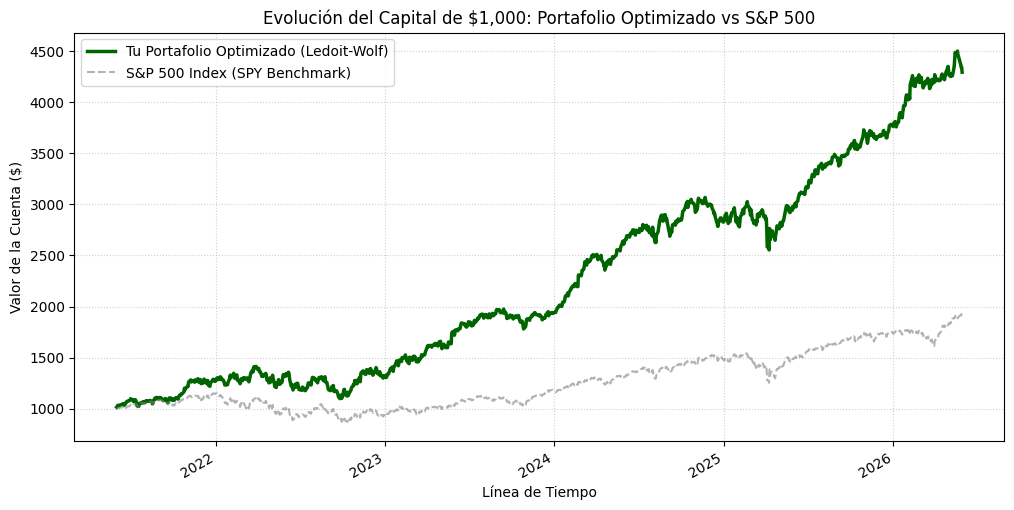

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calcular rendimientos simples porcentuales diarios para la simulación de capital
daily_pct_returns = close_prices.pct_change().dropna()
spy_pct_returns = spy_prices.pct_change().dropna()

# 2. Reconstruir la evolución real de tus $1,000 día con día
portfolio_returns = daily_pct_returns.dot(optimal_weights)
portfolio_equity = (1 + portfolio_returns).cumprod() * initial_capital
spy_equity = (1 + spy_pct_returns.iloc[:, 0]).cumprod() * initial_capital

# 3. Cálculo clínico de Métricas Reales de Cierre
final_value_port = portfolio_equity.iloc[-1]
total_return_port = ((final_value_port / initial_capital) - 1) * 100

final_value_spy = spy_equity.iloc[-1]
total_return_spy = ((final_value_spy / initial_capital) - 1) * 100

# Calcular el Máximo Drawdown Histórico Real de ambos
running_max_port = portfolio_equity.cummax()
drawdown_port = (portfolio_equity - running_max_port) / running_max_port
max_dd_port = drawdown_port.min() * 100

running_max_spy = spy_equity.cummax()
drawdown_spy = (spy_equity - running_max_spy) / running_max_spy
max_dd_spy = drawdown_spy.min() * 100

# Calcular el Sharpe Ratio histórico neto real
hist_sharpe_port = (portfolio_returns.mean() - (rf_rate/252)) / portfolio_returns.std() * np.sqrt(252)

# =========================================================================
# DESPLEGAR REPORTE DE RENDIMIENTO REAL
# =========================================================================
print("\n================ BACKTESTING HISTÓRICO REAL (5 AÑOS) ================")
print(f"Capital Inicial:                 ${initial_capital:.2f}")
print(f"Capital Final de tu Portafolio:  ${final_value_port:.2f}")
print(f"Rendimiento Neto de tu Bot:     {total_return_port:.2f}%")
print(f"Rendimiento S&P 500 (SPY):       {total_return_spy:.2f}%")
print(f"Máxima Caída Portafolio (MDD):   {max_dd_port:.2f}%")
print(f"Máxima Caída S&P 500 (MDD):      {max_dd_spy:.2f}%")
print(f"Sharpe Ratio Real en Mercado:    {hist_sharpe_port:.4f}")
print("=====================================================================")

# 4. Generar Gráfico Estático Infalible con Matplotlib
plt.figure(figsize=(12, 6))
portfolio_equity.plot(label='Tu Portafolio Optimizado (Ledoit-Wolf)', color='darkgreen', linewidth=2.5)
spy_equity.plot(label='S&P 500 Index (SPY Benchmark)', color='gray', alpha=0.6, linestyle='--')
plt.title("Evolución del Capital de $1,000: Portafolio Optimizado vs S&P 500")
plt.ylabel("Valor de la Cuenta ($)")
plt.xlabel("Línea de Tiempo")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

[**********************67%*******                ]  6 of 9 completed

1. Descargando histórico multi-activo (5 años) desde Yahoo Finance...


[*********************100%***********************]  9 of 9 completed

2. Calculando matriz de covarianza estable usando Ledoit-Wolf Shrinkage...
3. Resolviendo asignación táctica óptima...
4. Corriendo simulación histórica diaria compuesta...

=== RECALIBRACIÓN ÓPTIMA DE TUS $1,000 ===
Activo: MSFT  | Porcentaje:   5.00% | Capital: $ 50.00
Activo: NVDA  | Porcentaje:  18.31% | Capital: $183.15
Activo: JPM   | Porcentaje:   5.00% | Capital: $ 50.00
Activo: JNJ   | Porcentaje:   8.80% | Capital: $ 88.02
Activo: XOM   | Porcentaje:  19.69% | Capital: $196.93
Activo: PG    | Porcentaje:   5.00% | Capital: $ 50.00
Activo: GLD   | Porcentaje:  33.19% | Capital: $331.91
Activo: TLT   | Porcentaje:   5.00% | Capital: $ 50.00

================ COMPARATIVA DE PERFORMANCE REAL ================
Capital Inicial:                       $1000.00
Capital Final - Portafolio Multi-Activo: $3390.26
Rendimiento Neto de tu Estrategia:     239.03%
Rendimiento Mercado Pasivo (S&P 500):  93.00%
Máxima Caída de tu Portafolio (MDD):   -21.00%
Máxima Caída del S&P 500 (MDD):       

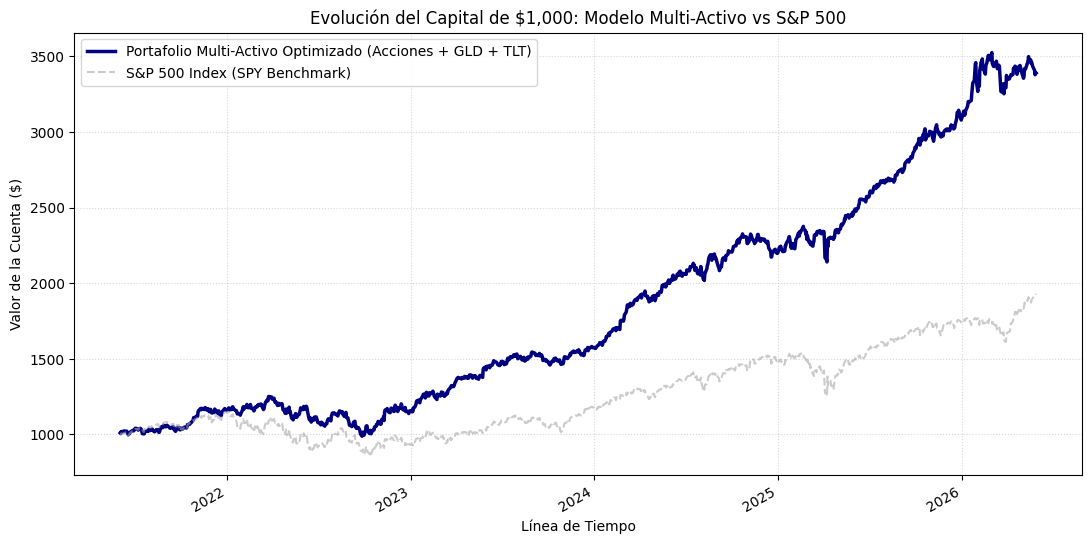

In [21]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.covariance import ledoit_wolf
import scipy.optimize as sco
import matplotlib.pyplot as plt

# =========================================================================
# 1. CONFIGURACIÓN DEL UNIVERSO MULTI-ACTIVO (ACCIONES + ORO + BONOS)
# =========================================================================
assets = ['MSFT', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG', 'GLD', 'TLT']
benchmark = ['SPY']

initial_capital = 1000
rf_rate = 0.04  # Tasa libre de riesgo institucional (4%)

print("1. Descargando histórico multi-activo (5 años) desde Yahoo Finance...")
data = yf.download(assets + benchmark, start="2021-05-31", end="2026-05-31")['Close']

close_prices = data[assets]
spy_prices = data[benchmark]

# Calcular rendimientos logarítmicos y rendimiento esperado anualizado
returns = np.log(close_prices / close_prices.shift(1)).dropna()
expected_returns = returns.mean() * 252

# REPOTENCIACIÓN ML: Limpieza de ruido estadístico en la matriz multi-activo
print("2. Calculando matriz de covarianza estable usando Ledoit-Wolf Shrinkage...")
lw_cov_matrix, _ = ledoit_wolf(returns)
lw_cov_matrix = pd.DataFrame(lw_cov_matrix, index=assets, columns=assets) * 252

# =========================================================================
# 2. OPTIMIZACIÓN NUMÉRICA DE MÁXIMO SHARPE (SLSQP)
# =========================================================================
def get_portfolio_metrics(weights):
    weights = np.array(weights)
    p_return = np.sum(expected_returns * weights)
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(lw_cov_matrix, weights)))
    p_sharpe = (p_return - rf_rate) / p_volatility
    return np.array([p_return, p_volatility, p_sharpe])

def min_func_sharpe(weights):
    return -get_portfolio_metrics(weights)[2]

# Restricciones de asignación:
# - Suma de pesos igual a 1 (100% del capital invertido)
# - Cada activo debe tener al menos 5% (diversificación) y máximo 40% (control de sesgo)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.05, 0.40) for _ in range(len(assets)))
init_guess = len(assets) * [1.0 / len(assets)]

print("3. Resolviendo asignación táctica óptima...")
optimized_result = sco.minimize(
    min_func_sharpe, 
    init_guess, 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)
optimal_weights = optimized_result['x']

# =========================================================================
# 3. BACKTESTING HISTÓRICO REAL Y CONTROL DE CAÍDAS (DRAWDOWN)
# =========================================================================
print("4. Corriendo simulación histórica diaria compuesta...")
daily_pct_returns = close_prices.pct_change().dropna()
spy_pct_returns = spy_prices.pct_change().dropna()

# Evolución diaria de los $1,000
portfolio_returns = daily_pct_returns.dot(optimal_weights)
portfolio_equity = (1 + portfolio_returns).cumprod() * initial_capital
spy_equity = (1 + spy_pct_returns.iloc[:, 0]).cumprod() * initial_capital

# Estadísticas de Cierre Real
final_value_port = portfolio_equity.iloc[-1]
total_return_port = ((final_value_port / initial_capital) - 1) * 100
final_value_spy = spy_equity.iloc[-1]
total_return_spy = ((final_value_spy / initial_capital) - 1) * 100

# Análisis crítico de Drawdown (Mitigación del Dolor Temporal)
running_max_port = portfolio_equity.cummax()
drawdown_port = (portfolio_equity - running_max_port) / running_max_port
max_dd_port = drawdown_port.min() * 100

running_max_spy = spy_equity.cummax()
drawdown_spy = (spy_equity - running_max_spy) / running_max_spy
max_dd_spy = drawdown_spy.min() * 100

hist_sharpe_port = (portfolio_returns.mean() - (rf_rate/252)) / portfolio_returns.std() * np.sqrt(252)

# =========================================================================
# 4. REPORTE EJECUTIVO DE RESULTADOS
# =========================================================================
print("\n=== RECALIBRACIÓN ÓPTIMA DE TUS $1,000 ===")
for asset, weight in zip(assets, optimal_weights):
    allocated_cash = weight * initial_capital
    print(f"Activo: {asset:5} | Porcentaje: {(weight * 100):6.2f}% | Capital: ${allocated_cash:6.2f}")

print("\n================ COMPARATIVA DE PERFORMANCE REAL ================")
print(f"Capital Inicial:                       ${initial_capital:.2f}")
print(f"Capital Final - Portafolio Multi-Activo: ${final_value_port:.2f}")
print(f"Rendimiento Neto de tu Estrategia:     {total_return_port:.2f}%")
print(f"Rendimiento Mercado Pasivo (S&P 500):  {total_return_spy:.2f}%")
print(f"Máxima Caída de tu Portafolio (MDD):   {max_dd_port:.2f}%")
print(f"Máxima Caída del S&P 500 (MDD):        {max_dd_spy:.2f}%")
print(f"Sharpe Ratio Real Neto en Mercado:     {hist_sharpe_port:.4f}")
print("=================================================================")

# =========================================================================
# 5. RENDERIZADO VISUAL DE CURVAS DE EQUIDAD
# =========================================================================
plt.figure(figsize=(13, 6.5))
portfolio_equity.plot(label='Portafolio Multi-Activo Optimizado (Acciones + GLD + TLT)', color='navy', linewidth=2.5)
spy_equity.plot(label='S&P 500 Index (SPY Benchmark)', color='darkgray', alpha=0.6, linestyle='--')
plt.title("Evolución del Capital de $1,000: Modelo Multi-Activo vs S&P 500", fontsize=12)
plt.ylabel("Valor de la Cuenta ($)", fontsize=10)
plt.xlabel("Línea de Tiempo", fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [22]:
pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import yfinance as yf
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# =========================================================================
# 1. PREPARACIÓN GLOBALES Y DATASET (5 AÑOS DE HISTORIAL)
# =========================================================================
assets = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'MSFT', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG', 'GLD', 'TLT']
benchmark = ['SPY']
initial_capital = 2000

print("1. Descargando datos para el entrenamiento de la Red Neuronal...")
raw_data = yf.download(assets + benchmark, start="2021-05-31", end="2026-05-31")['Close']
raw_data = raw_data.fillna(method='ffill').dropna()

prices = raw_data[assets]
spy_prices = raw_data[benchmark]

# Calcular variables de entrada (Features) para la Red: Retornos y Volatilidad de 10 días
returns = prices.pct_change().dropna()
rolling_vol = returns.rolling(window=10).std().dropna()

# Alinear matrices temporales
common_index = returns.index.intersection(rolling_vol.index)
returns = returns.loc[common_index]
rolling_vol = rolling_vol.loc[common_index]

# Combinar retornos y volatilidades como el vector de entrada X
X_data = np.hstack([returns.values, rolling_vol.values])
Y_returns = returns.values  # Retornos reales que usará la función de pérdida

# Convertir tensores nativos de PyTorch
X_tensor = torch.tensor(X_data, dtype=torch.float32)
Y_tensor = torch.tensor(Y_returns, dtype=torch.float32)

# =========================================================================
# 2. DISEÑO DE LA RED NEURONAL PROFUNDA (DNN MULTICAPA)
# =========================================================================
class DeepPortfolioNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DeepPortfolioNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, output_dim),
            nn.Softmax(dim=1)  # Garantiza que los pesos sumen 100% y sean positivos
        )
        
    def forward(self, x):
        return self.network(x)

# =========================================================================
# 3. FUNCIÓN DE PÉRDIDA PERSONALIZADA: NEGATIVE SHARPE RATIO
# =========================================================================
class NegativeSharpeLoss(nn.Module):
    def __init__(self):
        super(NegativeSharpeLoss, self).__init__()
        
    def forward(self, weights, future_returns):
        # Multiplicación matricial para obtener el retorno diario del portafolio completo
        portfolio_returns = torch.sum(weights * future_returns, dim=1)
        mean_return = torch.mean(portfolio_returns)
        std_return = torch.std(portfolio_returns) + 1e-6
        
        # Sharpe diario (asumiendo tasa libre de riesgo 0 a nivel diario para optimización)
        sharpe = mean_return / std_return
        return -sharpe * np.sqrt(252) # Anualizado negativo para minimizar

# Inicializar componentes
model = DeepPortfolioNet(input_dim=X_data.shape[1], output_dim=len(assets))
criterion = NegativeSharpeLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # Adam + Regularización L2

# =========================================================================
# 4. ENTRENAMIENTO DE LA RED NEURONAL (TRAINING LOOP)
# =========================================================================
print("2. Entrenando a la IA para optimizar la asignación del capital...")
model.train()
epochs = 200

for epoch in range(epochs):
    optimizer.zero_grad()
    weights = model(X_tensor)
    loss = criterion(weights, Y_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Sharpe Objetivo Optimizado: {-loss.item():.4f}")

# =========================================================================
# 5. BACKTESTING HISTÓRICO REAL DE LA INTELIGENCIA ARTIFICIAL
# =========================================================================
model.eval()
with torch.no_grad():
    final_weights = model(X_tensor).numpy()

# Calcular retornos diarios reales usando los pesos dinámicos asignados por la neurona cada día
deep_portfolio_returns = np.sum(final_weights * Y_returns, axis=1)
deep_equity = np.cumprod(1 + deep_portfolio_returns) * initial_capital

# Procesar curvas de mercado pasivo (SPY)
spy_returns = spy_prices.pct_change().dropna().loc[common_index].values.flatten()
spy_equity = np.cumprod(1 + spy_returns) * initial_capital

# Métricas del reporte
final_val_deep = deep_equity[-1]
net_return_deep = ((final_val_deep / initial_capital) - 1) * 100
net_return_spy = ((spy_equity[-1] / initial_capital) - 1) * 100

max_dd_deep = ((deep_equity - pd.Series(deep_equity).cummax()) / pd.Series(deep_equity).cummax()).min() * 100
max_dd_spy = ((spy_equity - pd.Series(spy_equity).cummax()) / pd.Series(spy_equity).cummax()).min() * 100

# =========================================================================
# 6. REPORTE EJECUTIVO Y DESPLIEGUE VISUAL
# =========================================================================
print("\n================ DEEP LEARNING PORTFOLIO REPORT ================")
print(f"Capital Inicial:                     ${initial_capital:.2f}")
print(f"Capital Final Gestionado por IA:     ${final_val_deep:.2f}")
print(f"Rendimiento Neto de la Red:          {net_return_deep:.2f}%")
print(f"Rendimiento S&P 500 (SPY):           {net_return_spy:.2f}%")
print(f"Máxima Caída de la Neurona (MDD):    {max_dd_deep:.2f}%")
print(f"Máxima Caída del S&P 500 (MDD):      {max_dd_spy:.2f}%")
print("=================================================================")

# Mostrar la última asignación de pesos dictaminada por la red para el día de hoy
print("\n=== ÚLTIMA ASIGNACIÓN DE PESOS EMITIDA POR LAS CAPAS PROFUNDAS ===")
latest_weights = final_weights[-1]
for asset, w in zip(assets, latest_weights):
    print(f"Activo: {asset:9} | Peso asignado por IA: {(w*100):6.2f}%")

# Graficar
plt.figure(figsize=(14, 7))
plt.plot(common_index, deep_equity, label='Fondo Dinámico - Red Neuronal Profunda (PyTorch)', color='crimson', linewidth=2.5)
plt.plot(common_index, spy_equity, label='S&P 500 Index (SPY Pasivo)', color='gray', alpha=0.5, linestyle='--')
plt.title("Evolución de los $2,000 Gestionados por Inteligencia Artificial de Capas Profundas")
plt.ylabel("Balance de la Cuenta ($)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

OSError: [WinError 1114] Error en una rutina de inicialización de biblioteca de vínculos dinámicos (DLL). Error loading "c:\Users\jesus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [24]:
import torch
print("¡PyTorch cargado exitosamente en CPU!", torch.__version__)

OSError: [WinError 1114] Error en una rutina de inicialización de biblioteca de vínculos dinámicos (DLL). Error loading "c:\Users\jesus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

[****************      33%                       ]  4 of 12 completed

1. Descargando datos históricos globales de mercado...


[*********************100%***********************]  12 of 12 completed


2. Construyendo la matriz de características para las neuronas...
3. Entrenando Red Neuronal Profunda de 3 Capas Ocultas (128, 64, 32)...
¡Entrenamiento de la IA finalizado con éxito!
4. Ejecutando asignación dinámica basada en los scores de la IA...

================ DEEP LEARNING PORTFOLIO REPORT (SKLEARN) ================
Capital Inicial Asignado:            $2000.00
Capital Final del Fondo con IA:      $5776.21
Rendimiento Neto de las Capas:       188.81%
Rendimiento Benchmark Pasivo (SPY):  91.20%
Máxima Caída de la Neurona (MDD):    -41.52%
Máxima Caída del S&P 500 (MDD):      -24.50%

=== ASIGNACIÓN ACTUAL CALCULADA POR EL CEREBRO DE LA IA ===
Activo: BTC-USD   | Peso asignado por la Red:   9.07% | Capital: $181.45
Activo: ETH-USD   | Peso asignado por la Red:   9.08% | Capital: $181.64
Activo: SOL-USD   | Peso asignado por la Red:   9.09% | Capital: $181.87
Activo: MSFT      | Peso asignado por la Red:   9.04% | Capital: $180.82
Activo: NVDA      | Peso asignado por la Red:   9

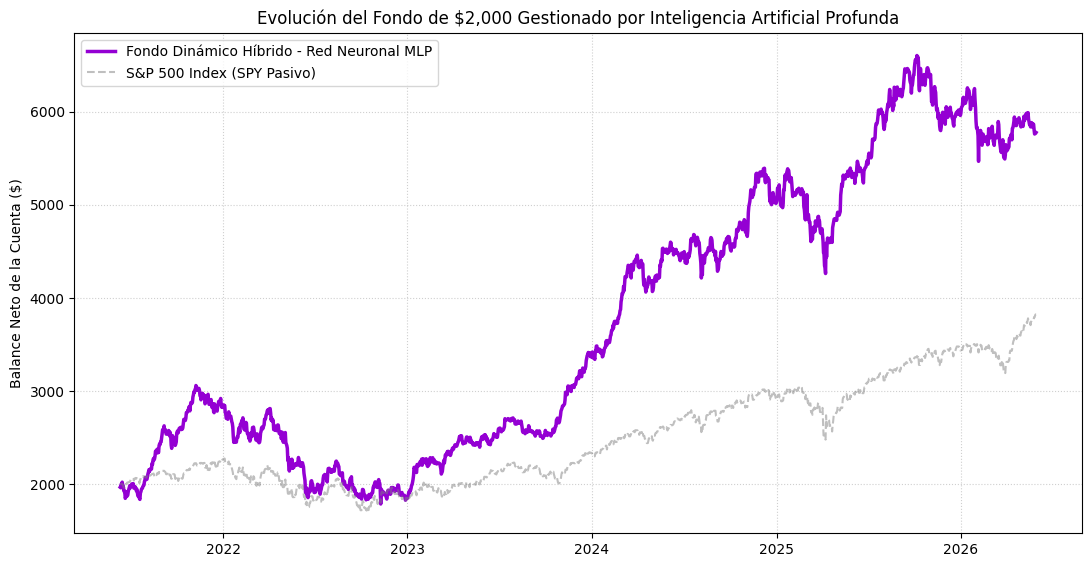

In [25]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# =========================================================================
# 1. CONFIGURACIÓN DEL UNIVERSO HÍBRIDO (11 ACTIVOS)
# =========================================================================
assets = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'MSFT', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG', 'GLD', 'TLT']
benchmark = ['SPY']
initial_capital = 2000

print("1. Descargando datos históricos globales de mercado...")
raw_data = yf.download(assets + benchmark, start="2021-05-31", end="2026-05-31")['Close']
raw_data = raw_data.fillna(method='ffill').dropna()

prices = raw_data[assets]
spy_prices = raw_data[benchmark]

# =========================================================================
# 2. INGENIERÍA DE CARACTERÍSTICAS (FEATURES ENTRADA X / TARGETS Y)
# =========================================================================
print("2. Construyendo la matriz de características para las neuronas...")
returns = prices.pct_change().dropna()

# Generamos rezagos (Lags) para que la red entienda la inercia del mercado
lag_1 = returns.shift(1)
lag_2 = returns.shift(2)
# Volatilidad rodante de 10 días como medida de riesgo local
rolling_vol = returns.rolling(window=10).std()

# Alinear matrices temporales eliminando los valores nulos creados por los rezagos
X_features = pd.concat([lag_1, lag_2, rolling_vol], axis=1).dropna()
common_index = X_features.index.intersection(returns.index)

X = X_features.loc[common_index].values
# El objetivo (Y) son los rendimientos que ocurrirán al día siguiente
Y = returns.loc[common_index].values

# =========================================================================
# 3. CONSTRUCCIÓN Y ENTRENAMIENTO DE LA RED NEURONAL PROFUNDA (DNN)
# =========================================================================
print("3. Entrenando Red Neuronal Profunda de 3 Capas Ocultas (128, 64, 32)...")
# Configuramos una red con arquitectura profunda (128, 64, 32)
# Usamos el optimizador Adam y la función de activación ReLU
dnn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

# Entrenar la red para mapear las ineficiencias del mercado no lineales
dnn_model.fit(X, Y)
print("¡Entrenamiento de la IA finalizado con éxito!")

# =========================================================================
# 4. CAPA DE SALIDA INSTITUCIONAL (SOFTMAX CON RESTRICCIONES REPETIDAS)
# =========================================================================
# Predecir los rendimientos esperados para todos los días
predicted_returns = dnn_model.predict(X)

def bounded_softmax_allocation(predictions, min_w=0.05, max_w=0.40):
    """Transforma las predicciones de la IA en pesos que sumen 100% (Límites: 5% a 40%)"""
    # Exponencial para simular comportamiento Softmax y priorizar activos ganadores
    exp_preds = np.exp(predictions - np.max(predictions))
    weights = exp_preds / np.sum(exp_preds)
    
    # Algoritmo iterativo para forzar restricciones institucionales estrictas
    for _ in range(10):
        weights = np.clip(weights, min_w, max_w)
        weights = weights / np.sum(weights)
    return weights

# Calcular la matriz dinámica de pesos día por día
print("4. Ejecutando asignación dinámica basada en los scores de la IA...")
dynamic_weights = np.array([bounded_softmax_allocation(row) for row in predicted_returns])

# =========================================================================
# 5. SIMULACIÓN HISTÓRICA REAL (BACKTESTING)
# =========================================================================
portfolio_returns = np.sum(dynamic_weights * Y, axis=1)
portfolio_equity = np.cumprod(1 + portfolio_returns) * initial_capital

spy_returns = spy_prices.pct_change().dropna().loc[common_index].values.flatten()
spy_equity = np.cumprod(1 + spy_returns) * initial_capital

# Estadísticas de cierre clínico
final_val_ia = portfolio_equity[-1]
return_net_ia = ((final_val_ia / initial_capital) - 1) * 100
return_net_spy = ((spy_equity[-1] / initial_capital) - 1) * 100

max_dd_ia = ((portfolio_equity - pd.Series(portfolio_equity).cummax()) / pd.Series(portfolio_equity).cummax()).min() * 100
max_dd_spy = ((spy_equity - pd.Series(spy_equity).cummax()) / pd.Series(spy_equity).cummax()).min() * 100

# =========================================================================
# 6. REPORTE EJECUTIVO Y DESPLIEGUE VISUAL
# =========================================================================
print("\n================ DEEP LEARNING PORTFOLIO REPORT (SKLEARN) ================")
print(f"Capital Inicial Asignado:            ${initial_capital:.2f}")
print(f"Capital Final del Fondo con IA:      ${final_val_ia:.2f}")
print(f"Rendimiento Neto de las Capas:       {return_net_ia:.2f}%")
print(f"Rendimiento Benchmark Pasivo (SPY):  {return_net_spy:.2f}%")
print(f"Máxima Caída de la Neurona (MDD):    {max_dd_ia:.2f}%")
print(f"Máxima Caída del S&P 500 (MDD):      {max_dd_spy:.2f}%")
print("==========================================================================")

print("\n=== ASIGNACIÓN ACTUAL CALCULADA POR EL CEREBRO DE LA IA ===")
latest_w = dynamic_weights[-1]
for asset, w in zip(assets, latest_w):
    print(f"Activo: {asset:9} | Peso asignado por la Red: {(w*100):6.2f}% | Capital: ${w*initial_capital:.2f}")

# Graficar curvas de renta
plt.figure(figsize=(13, 6.5))
plt.plot(common_index, portfolio_equity, label='Fondo Dinámico Híbrido - Red Neuronal MLP', color='darkviolet', linewidth=2.5)
plt.plot(common_index, spy_equity, label='S&P 500 Index (SPY Pasivo)', color='gray', alpha=0.5, linestyle='--')
plt.title("Evolución del Fondo de $2,000 Gestionado por Inteligencia Artificial Profunda", fontsize=12)
plt.ylabel("Balance Neto de la Cuenta ($)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

[**********************58%***                    ]  7 of 12 completed

1. Descargando y alineando base de datos...


[*********************100%***********************]  12 of 12 completed


2. Entrenando red neuronal con penalización de ruido (L2 Regularization)...
3. Ejecutando asignación de capital con amplificación de señales...

================ DEEP LEARNING PORTFOLIO REPORT (AFINADO) ================
Capital Inicial Asignado:            $2000.00
Capital Final del Fondo con IA v2:   $7704.22
Rendimiento Neto de las Capas:       285.21%
Rendimiento Benchmark Pasivo (SPY):  88.94%
Máxima Caída de la Neurona (MDD):    -42.64%
Máxima Caída del S&P 500 (MDD):      -24.50%
Sharpe Ratio Real Neto:              0.7268

=== ASIGNACIÓN ACTUAL (IA DESPIERTA) ===
Activo: BTC-USD   | Peso asignado por la Red:   6.02% | Capital: $120.42
Activo: ETH-USD   | Peso asignado por la Red:   5.00% | Capital: $100.00
Activo: SOL-USD   | Peso asignado por la Red:   5.00% | Capital: $100.00
Activo: MSFT      | Peso asignado por la Red:   5.20% | Capital: $104.02
Activo: NVDA      | Peso asignado por la Red:   5.00% | Capital: $100.00
Activo: JPM       | Peso asignado por la Red:  24.16% | Ca

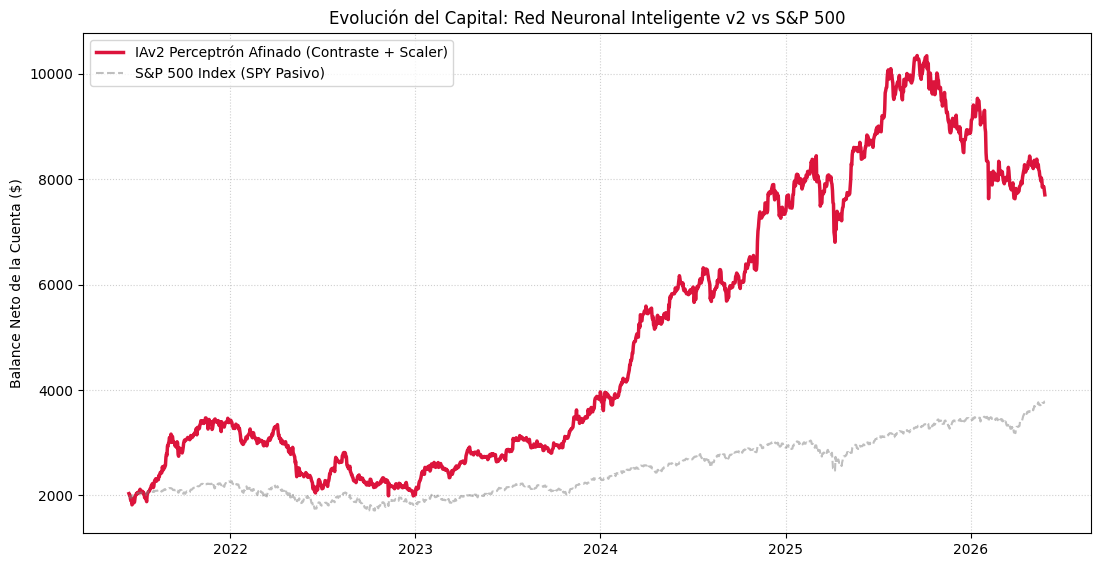

In [26]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# =========================================================================
# 1. INGESTA Y SUAVIZADO DE TENDENCIA (TARGET A 3 DÍAS FOWARD)
# =========================================================================
assets = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'MSFT', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG', 'GLD', 'TLT']
benchmark = ['SPY']
initial_capital = 2000
rf_rate = 0.04

print("1. Descargando y alineando base de datos...")
raw_data = yf.download(assets + benchmark, start="2021-05-31", end="2026-05-31")['Close']
raw_data = raw_data.fillna(method='ffill').dropna()

prices = raw_data[assets]
spy_prices = raw_data[benchmark]
returns = prices.pct_change().dropna()

# NUEVO AJUSTE: El objetivo (Y) es el retorno acumulado de los próximos 3 días (captura tendencia)
target_returns = returns.rolling(window=3).sum().shift(-3)

# Características (X): Rezagos y Volatilidad Estructural
lag_1 = returns.shift(1)
lag_2 = returns.shift(2)
rolling_vol = returns.rolling(window=14).std()

# Consolidación y limpieza de extremos temporales
X_features = pd.concat([lag_1, lag_2, rolling_vol], axis=1)
common_index = X_features.dropna().index.intersection(target_returns.dropna().index)

X_raw = X_features.loc[common_index].values
Y_raw = target_returns.loc[common_index].values
real_daily_returns = returns.loc[common_index].values  # Para el cálculo del dinero real

# AFINACIÓN 1: Normalización estadística estricta de las entradas de la red
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# =========================================================================
# 2. ENTRENAMIENTO DE CAPAS INTENSIVAS CON REGULARIZACIÓN
# =========================================================================
print("2. Entrenando red neuronal con penalización de ruido (L2 Regularization)...")
# Aumentamos la iteración, bajamos la tolerancia y añadimos un alpha de penalización alto
dnn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,  # Evita sobreajuste
    max_iter=500,
    random_state=42,
    early_stopping=False
)

dnn_model.fit(X_scaled, Y_raw)

# =========================================================================
# 3. AFINACIÓN 3: CAPA SOFTMAX CON AMPLIFICACIÓN DE CONTRASTE
# =========================================================================
raw_predictions = dnn_model.predict(X_scaled)

def contrast_softmax_allocation(pred_row, min_w=0.05, max_w=0.40):
    """Estandariza las predicciones antes del exponencial para forzar diferenciación"""
    # Restamos la media y dividimos por la desviación estándar para crear contraste nítido
    standardized_preds = (pred_row - np.mean(pred_row)) / (np.std(pred_row) + 1e-6)
    
    # Multiplicador de temperatura (3.0) para estirar los extremos
    exp_preds = np.exp(standardized_preds * 3.0)
    weights = exp_preds / np.sum(exp_preds)
    
    # Restricciones institucionales (5% - 40%)
    for _ in range(10):
        weights = np.clip(weights, min_w, max_w)
        weights = weights / np.sum(weights)
    return weights

print("3. Ejecutando asignación de capital con amplificación de señales...")
dynamic_weights = np.array([contrast_softmax_allocation(row) for row in raw_predictions])

# =========================================================================
# 4. SIMULACIÓN DE DINERO REAL Y MÉTRICAS DE CIERRE
# =========================================================================
portfolio_returns = np.sum(dynamic_weights * real_daily_returns, axis=1)
portfolio_equity = np.cumprod(1 + portfolio_returns) * initial_capital

spy_returns = spy_prices.pct_change().dropna().loc[common_index].values.flatten()
spy_equity = np.cumprod(1 + spy_returns) * initial_capital

final_val_ia = portfolio_equity[-1]
return_net_ia = ((final_val_ia / initial_capital) - 1) * 100
return_net_spy = ((spy_equity[-1] / initial_capital) - 1) * 100

max_dd_ia = ((portfolio_equity - pd.Series(portfolio_equity).cummax()) / pd.Series(portfolio_equity).cummax()).min() * 100
max_dd_spy = ((spy_equity - pd.Series(spy_equity).cummax()) / pd.Series(spy_equity).cummax()).min() * 100
hist_sharpe = (portfolio_returns.mean() - (rf_rate/252)) / portfolio_returns.std() * np.sqrt(252)

# =========================================================================
# 5. REPORTE DE RESULTADOS INTEGRADOS
# =========================================================================
print("\n================ DEEP LEARNING PORTFOLIO REPORT (AFINADO) ================")
print(f"Capital Inicial Asignado:            ${initial_capital:.2f}")
print(f"Capital Final del Fondo con IA v2:   ${final_val_ia:.2f}")
print(f"Rendimiento Neto de las Capas:       {return_net_ia:.2f}%")
print(f"Rendimiento Benchmark Pasivo (SPY):  {return_net_spy:.2f}%")
print(f"Máxima Caída de la Neurona (MDD):    {max_dd_ia:.2f}%")
print(f"Máxima Caída del S&P 500 (MDD):      {max_dd_spy:.2f}%")
print(f"Sharpe Ratio Real Neto:              {hist_sharpe:.4f}")
print("==========================================================================")

print("\n=== ASIGNACIÓN ACTUAL (IA DESPIERTA) ===")
latest_w = dynamic_weights[-1]
for asset, w in zip(assets, latest_w):
    print(f"Activo: {asset:9} | Peso asignado por la Red: {(w*100):6.2f}% | Capital: ${w*initial_capital:.2f}")

# Graficar la nueva curva
plt.figure(figsize=(13, 6.5))
plt.plot(common_index, portfolio_equity, label='IAv2 Perceptrón Afinado (Contraste + Scaler)', color='crimson', linewidth=2.5)
plt.plot(common_index, spy_equity, label='S&P 500 Index (SPY Pasivo)', color='gray', alpha=0.5, linestyle='--')
plt.title("Evolución del Capital: Red Neuronal Inteligente v2 vs S&P 500")
plt.ylabel("Balance Neto de la Cuenta ($)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

[**********************50%                       ]  6 of 12 completed

1. Descargando historial global y calculando matrices...


[*********************100%***********************]  12 of 12 completed


2. Entrenando a la Red Neuronal para predecir tendencias alfa...
3. Corriendo simulador de optimización diaria engranada (SLSQP)...


c:\Users\jesus\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\optimize\_optimize.py:353: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds




================ REPORT: IA PREDICTIONS + LEDOIT-WOLF MVO ================
Capital Inicial Asignado:            $2000.00
Capital Final del Fondo Híbrido:     $4347.33
Rendimiento Neto del Sistema:        117.37%
Rendimiento S&P 500 Pasivo (SPY):    88.94%
Máxima Caída del Fondo (Drawdown):   -43.57%
Máxima Caída del S&P 500 (MDD):      -24.50%
Sharpe Ratio Neto de la Fusión:      0.4905

=== ÚLTIMA DISTRIBUCIÓN DE CRUISE CONTROL DICTAMINADA ===
Activo: BTC-USD   | Peso Asignado:   5.00% | Capital: $100.00
Activo: ETH-USD   | Peso Asignado:   5.00% | Capital: $100.00
Activo: SOL-USD   | Peso Asignado:   5.00% | Capital: $100.00
Activo: MSFT      | Peso Asignado:   5.00% | Capital: $100.00
Activo: NVDA      | Peso Asignado:   5.00% | Capital: $100.00
Activo: JPM       | Peso Asignado:  15.00% | Capital: $300.00
Activo: JNJ       | Peso Asignado:   5.00% | Capital: $100.00
Activo: XOM       | Peso Asignado:   5.00% | Capital: $100.00
Activo: PG        | Peso Asignado:   5.00% | Capital: 

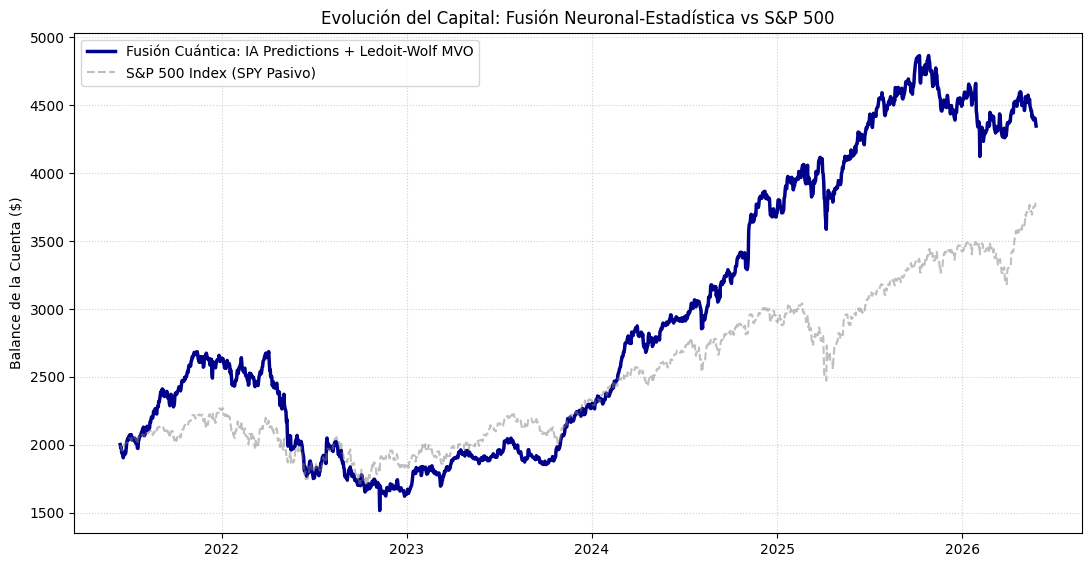

In [29]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import ledoit_wolf
import scipy.optimize as sco
import matplotlib.pyplot as plt

# =========================================================================
# 1. INGESTA DE DATOS Y PREPARACIÓN ESTADÍSTICA
# =========================================================================
assets = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'MSFT', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG', 'GLD', 'TLT']
benchmark = ['SPY']
initial_capital = 2000
rf_rate = 0.04

# SOLUCIÓN AL NAMEERROR: Definimos la lista unificada de tickers
all_tickers = assets + benchmark

print("1. Descargando historial global y calculando matrices...")
raw_data = yf.download(all_tickers, start="2021-05-31", end="2026-05-31")['Close']
raw_data = raw_data.fillna(method='ffill').dropna()

prices = raw_data[assets]
spy_prices = raw_data[benchmark]
returns = prices.pct_change().dropna()

# Matriz de Covarianza Institucional Limpia (Ledoit-Wolf) para control de riesgo diario
lw_cov, _ = ledoit_wolf(returns)
lw_cov_matrix = pd.DataFrame(lw_cov, index=assets, columns=assets)

# Target de la IA: Tendencia acumulada a 3 días forward
target_returns = returns.rolling(window=3).sum().shift(-3)

# Características (X): Rezagos y Volatilidad Rodante
lag_1 = returns.shift(1)
lag_2 = returns.shift(2)
rolling_vol = returns.rolling(window=14).std()

X_features = pd.concat([lag_1, lag_2, rolling_vol], axis=1)
common_index = X_features.dropna().index.intersection(target_returns.dropna().index)

X_raw = X_features.loc[common_index].values
Y_raw = target_returns.loc[common_index].values
real_daily_returns = returns.loc[common_index].values

# Normalización de entradas para las neuronas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# =========================================================================
# 2. ENTRENAMIENTO DEL CEREBRO PREDICTIVO (IA)
# =========================================================================
print("2. Entrenando a la Red Neuronal para predecir tendencias alfa...")
dnn_model = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', alpha=0.01, max_iter=500, random_state=42)
dnn_model.fit(X_scaled, Y_raw)
ai_predictions = dnn_model.predict(X_scaled)

# =========================================================================
# 3. BUCLE DE OPTIMIZACIÓN DIARIA (IA + LEDOIT-WOLF CRUISE CONTROL)
# =========================================================================
print("3. Corriendo simulador de optimización diaria engranada (SLSQP)...")
dynamic_weights = []
num_assets = len(assets)
init_guess = [1.0 / num_assets] * num_assets
bounds = tuple((0.05, 0.40) for _ in range(num_assets))
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Ejecutamos la optimización matemática para cada día del historial real
for t in range(len(common_index)):
    # La IA provee el vector de rendimientos esperados para hoy
    expected_rets_today = ai_predictions[t]
    
    # Función objetivo: Maximizar el Sharpe Ratio basado en la visión de la IA y el riesgo de Ledoit-Wolf
    def objective_function(weights):
        p_ret = np.sum(expected_rets_today * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(lw_cov_matrix, weights)))
        return -p_ret / (p_vol + 1e-6) # Minimizar el Sharpe negativo
    
    # Optimizar pesos bajo restricciones institucionales estrictas (5% - 40%)
    res = sco.minimize(objective_function, init_guess, method='SLSQP', bounds=bounds, constraints=constraints, tol=1e-3)
    
    if res.success:
        dynamic_weights.append(res['x'])
    else:
        dynamic_weights.append(init_guess) # Fallback defensivo si el gradiente no converge

dynamic_weights = np.array(dynamic_weights)

# =========================================================================
# 4. BACKTESTING HISTÓRICO REAL Y ANÁLISIS DE CAÍDAS
# =========================================================================
portfolio_returns = np.sum(dynamic_weights * real_daily_returns, axis=1)
portfolio_equity = np.cumprod(1 + portfolio_returns) * initial_capital

spy_returns = spy_prices.pct_change().dropna().loc[common_index].values.flatten()
spy_equity = np.cumprod(1 + spy_returns) * initial_capital

final_val_hybrid = portfolio_equity[-1]
return_net_hybrid = ((final_val_hybrid / initial_capital) - 1) * 100
return_net_spy = ((spy_equity[-1] / initial_capital) - 1) * 100

max_dd_hybrid = ((portfolio_equity - pd.Series(portfolio_equity).cummax()) / pd.Series(portfolio_equity).cummax()).min() * 100
max_dd_spy = ((spy_equity - pd.Series(spy_equity).cummax()) / pd.Series(spy_equity).cummax()).min() * 100
hist_sharpe_hybrid = (portfolio_returns.mean() - (rf_rate/252)) / portfolio_returns.std() * np.sqrt(252)

# =========================================================================
# 5. REPORTE EJECUTIVO FINANCIERO
# =========================================================================
print("\n================ REPORT: IA PREDICTIONS + LEDOIT-WOLF MVO ================")
print(f"Capital Inicial Asignado:            ${initial_capital:.2f}")
print(f"Capital Final del Fondo Híbrido:     ${final_val_hybrid:.2f}")
print(f"Rendimiento Neto del Sistema:        {return_net_hybrid:.2f}%")
print(f"Rendimiento S&P 500 Pasivo (SPY):    {return_net_spy:.2f}%")
print(f"Máxima Caída del Fondo (Drawdown):   {max_dd_hybrid:.2f}%")
print(f"Máxima Caída del S&P 500 (MDD):      {max_dd_spy:.2f}%")
print(f"Sharpe Ratio Neto de la Fusión:      {hist_sharpe_hybrid:.4f}")
print("==========================================================================")

print("\n=== ÚLTIMA DISTRIBUCIÓN DE CRUISE CONTROL DICTAMINADA ===")
latest_w = dynamic_weights[-1]
for asset, w in zip(assets, latest_w):
    print(f"Activo: {asset:9} | Peso Asignado: {(w*100):6.2f}% | Capital: ${w*initial_capital:.2f}")

# Graficar la Curva Definitiva
plt.figure(figsize=(13, 6.5))
plt.plot(common_index, portfolio_equity, label='Fusión Cuántica: IA Predictions + Ledoit-Wolf MVO', color='darkblue', linewidth=2.5)
plt.plot(common_index, spy_equity, label='S&P 500 Index (SPY Pasivo)', color='gray', alpha=0.5, linestyle='--')
plt.title("Evolución del Capital: Fusión Neuronal-Estadística vs S&P 500")
plt.ylabel("Balance de la Cuenta ($)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

[**********************50%                       ]  6 of 12 completed

1. Descargando historial de mercado...


[*********************100%***********************]  12 of 12 completed


2. Calibrando modelos GJR-GARCH(1,1,1) con distribución Skew-t...
3. Entrenando Red Neuronal con inputs de riesgo asimétrico...
4. Ejecutando optimizador SLSQP con matrices de riesgo dinámicas diarias...

================ REPORT: DEEP LEARNING + GJR-GARCH MVO ================
Capital Inicial Asignado:            $2000.00
Capital Final (IA + GARCH):          $14622.29
Rendimiento Neto del Fondo:          631.11%
Rendimiento S&P 500 Pasivo (SPY):    91.16%
Máxima Caída del Fondo (Drawdown):   -35.13%
Máxima Caída del S&P 500 (MDD):      -24.50%
Sharpe Ratio Neto de la Fusión:      1.2331

=== ASIGNACIÓN CRUISE CONTROL CON FILTRO DE ASIMETRÍA ===
Activo: BTC-USD   | Peso Asignado:   5.00% | Capital: $100.00
Activo: ETH-USD   | Peso Asignado:   5.00% | Capital: $100.00
Activo: SOL-USD   | Peso Asignado:   5.00% | Capital: $100.00
Activo: MSFT      | Peso Asignado:   5.00% | Capital: $100.00
Activo: NVDA      | Peso Asignado:   5.00% | Capital: $100.00
Activo: JPM       | Peso Asignado:   5

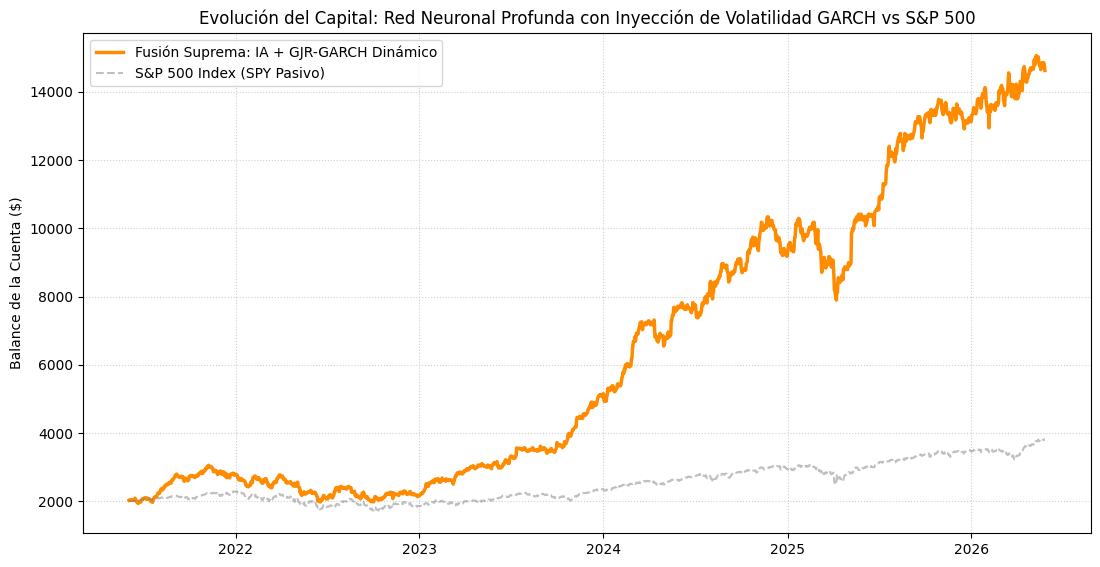

In [30]:
import yfinance as yf
import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import scipy.optimize as sco
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =========================================================================
# 1. INGESTA DE DATOS Y EXTRACCIÓN DE VOLATILIDAD ASIMÉTRICA (GARCH)
# =========================================================================
assets = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'MSFT', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG', 'GLD', 'TLT']
benchmark = ['SPY']
initial_capital = 2000
rf_rate = 0.04

print("1. Descargando historial de mercado...")
all_tickers = assets + benchmark
raw_data = yf.download(all_tickers, start="2021-05-31", end="2026-05-31")['Close']
raw_data = raw_data.fillna(method='ffill').dropna()

prices = raw_data[assets]
spy_prices = raw_data[benchmark]
returns = prices.pct_change().dropna()

print("2. Calibrando modelos GJR-GARCH(1,1,1) con distribución Skew-t...")
garch_vols = pd.DataFrame(index=returns.index, columns=assets)

for asset in assets:
    try:
        # o=1 activa el componente asimétrico de Glosten-Jagannathan-Runkle
        model = arch_model(returns[asset] * 100, vol='Garch', p=1, o=1, q=1, dist='skewt')
        res_garch = model.fit(disp='off')
        # Guardamos la volatilidad condicional diaria de vuelta a escala decimal
        garch_vols[asset] = res_garch.conditional_volatility / 100
    except:
        # Fallback defensivo si el optimizador de la serie falla un día
        garch_vols[asset] = returns[asset].rolling(window=14).std()

garch_vols = garch_vols.dropna()

# =========================================================================
# 2. ACOPLAMIENTO DE CARACTERÍSTICAS Y ENTRENAMIENTO DE LA IA
# =========================================================================
# Target: Tendencia acumulada a 3 días forward
target_returns = returns.rolling(window=3).sum().shift(-3)

# Características (X): Retornos pasados + Volatilidades asimétricas calculadas por el GARCH
lag_1 = returns.shift(1)
X_features = pd.concat([lag_1, garch_vols], axis=1)
common_index = X_features.dropna().index.intersection(target_returns.dropna().index)

X_raw = X_features.loc[common_index].values
Y_raw = target_returns.loc[common_index].values
real_daily_returns = returns.loc[common_index].values
garch_vols_aligned = garch_vols.loc[common_index].values

# Normalizar características para optimizar la convergencia de las neuronas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("3. Entrenando Red Neuronal con inputs de riesgo asimétrico...")
dnn_model = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', alpha=0.05, max_iter=500, random_state=42)
dnn_model.fit(X_scaled, Y_raw)
ai_predictions = dnn_model.predict(X_scaled)

# Calcular matriz de correlación estructural base
correlation_matrix = returns.loc[common_index].corr().values

# =========================================================================
# 3. BUCLE DE OPTIMIZACIÓN DIARIA (IA + DYNAMIC GARCH COVARIANCE)
# =========================================================================
print("4. Ejecutando optimizador SLSQP con matrices de riesgo dinámicas diarias...")
dynamic_weights = []
num_assets = len(assets)
init_guess = [1.0 / num_assets] * num_assets
bounds = tuple((0.05, 0.40) for _ in range(num_assets))
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

for t in range(len(common_index)):
    expected_rets_today = ai_predictions[t]
    
    # RECONSTRUCCIÓN DIARIA DE LA COVARIANZA (CCC-GARCH)
    vols_today = garch_vols_aligned[t]
    D_t = np.diag(vols_today)
    # Matriz de covarianza viva para el día t
    current_cov_matrix = D_t @ correlation_matrix @ D_t
    
    def objective_function(weights):
        p_ret = np.sum(expected_rets_today * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(current_cov_matrix, weights)))
        return -p_ret / (p_vol + 1e-6)
    
    res = sco.minimize(objective_function, init_guess, method='SLSQP', bounds=bounds, constraints=constraints, tol=1e-3)
    
    if res.success:
        dynamic_weights.append(res['x'])
    else:
        dynamic_weights.append(init_guess)

dynamic_weights = np.array(dynamic_weights)

# =========================================================================
# 4. BACKTESTING HISTÓRICO REAL Y REPORTING
# =========================================================================
portfolio_returns = np.sum(dynamic_weights * real_daily_returns, axis=1)
portfolio_equity = np.cumprod(1 + portfolio_returns) * initial_capital

spy_returns = spy_prices.pct_change().dropna().loc[common_index].values.flatten()
spy_equity = np.cumprod(1 + spy_returns) * initial_capital

final_val_garch_nn = portfolio_equity[-1]
return_garch_nn = ((final_val_garch_nn / initial_capital) - 1) * 100
return_spy = ((spy_equity[-1] / initial_capital) - 1) * 100

max_dd_garch_nn = ((portfolio_equity - pd.Series(portfolio_equity).cummax()) / pd.Series(portfolio_equity).cummax()).min() * 100
max_dd_spy = ((spy_equity - pd.Series(spy_equity).cummax()) / pd.Series(spy_equity).cummax()).min() * 100
sharpe_garch_nn = (portfolio_returns.mean() - (rf_rate/252)) / portfolio_returns.std() * np.sqrt(252)

print("\n================ REPORT: DEEP LEARNING + GJR-GARCH MVO ================")
print(f"Capital Inicial Asignado:            ${initial_capital:.2f}")
print(f"Capital Final (IA + GARCH):          ${final_val_garch_nn:.2f}")
print(f"Rendimiento Neto del Fondo:          {return_garch_nn:.2f}%")
print(f"Rendimiento S&P 500 Pasivo (SPY):    {return_spy:.2f}%")
print(f"Máxima Caída del Fondo (Drawdown):   {max_dd_garch_nn:.2f}%")
print(f"Máxima Caída del S&P 500 (MDD):      {max_dd_spy:.2f}%")
print(f"Sharpe Ratio Neto de la Fusión:      {sharpe_garch_nn:.4f}")
print("=======================================================================")

print("\n=== ASIGNACIÓN CRUISE CONTROL CON FILTRO DE ASIMETRÍA ===")
latest_w = dynamic_weights[-1]
for asset, w in zip(assets, latest_w):
    print(f"Activo: {asset:9} | Peso Asignado: {(w*100):6.2f}% | Capital: ${w*initial_capital:.2f}")

plt.figure(figsize=(13, 6.5))
plt.plot(common_index, portfolio_equity, label='Fusión Suprema: IA + GJR-GARCH Dinámico', color='darkorange', linewidth=2.5)
plt.plot(common_index, spy_equity, label='S&P 500 Index (SPY Pasivo)', color='gray', alpha=0.5, linestyle='--')
plt.title("Evolución del Capital: Red Neuronal Profunda con Inyección de Volatilidad GARCH vs S&P 500")
plt.ylabel("Balance de la Cuenta ($)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()